In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import pandas as pd

In [3]:
df = pd.read_csv('./train_heat_final.csv', encoding='utf-8')
df.head()

,ta_chi,branch_id,heat_demand,datetime,year,month,day,hour,dayofweek,dayofyear,...,heat_demand_lag24,ta_chi_lag3,ta_chi_lag24,heat_demand_roll_mean_3,heat_demand_roll_std_3,ta_chi_roll_mean_3,ta_chi_roll_std_3,work_time,weekend,holiday
0,-6.9,A,279.0,2021-01-02 01:00:00,2021,1,2,1,5,2,...,281.0,-4.9,-8.2,308.666667,2.309401,308.666667,2.309401,0,1,0
1,-7.9,A,272.0,2021-01-02 02:00:00,2021,1,2,2,5,2,...,262.0,-4.9,-8.6,303.666667,7.767453,303.666667,7.767453,0,1,0
2,-5.5,A,264.0,2021-01-02 03:00:00,2021,1,2,3,5,2,...,266.0,-6.6,-8.8,295.666667,10.016653,295.666667,10.016653,0,1,0
3,-6.0,A,269.0,2021-01-02 04:00:00,2021,1,2,4,5,2,...,285.0,-6.9,-8.9,286.666667,8.020806,286.666667,8.020806,0,1,0
4,-6.4,A,284.0,2021-01-02 05:00:00,2021,1,2,5,5,2,...,283.0,-7.9,-9.2,279.000000,7.000000,279.000000,7.000000,0,1,0


In [5]:
df = df.dropna()

In [10]:
df.isna().sum()

,0
ta_chi,0
branch_id,0
heat_demand,0
datetime,0
year,0
month,0
day,0
hour,0
dayofweek,0
dayofyear,0


In [7]:
df.describe()

,ta_chi,heat_demand,year,month,day,hour,dayofweek,dayofyear,weekofyear,branch_id_encoded,...,heat_demand_lag24,ta_chi_lag3,ta_chi_lag24,heat_demand_roll_mean_3,heat_demand_roll_std_3,ta_chi_roll_mean_3,ta_chi_roll_std_3,work_time,weekend,holiday
count,499277.000000,499277.000000,499277.000000,499277.000000,499277.000000,499277.000000,499277.000000,499277.000000,499277.000000,499277.000000,...,499277.000000,499277.000000,499277.000000,499277.000000,499277.000000,499277.000000,499277.000000,499277.000000,499277.000000,499277.000000
mean,13.875108,95.858863,2022.000086,6.526503,15.721814,11.500438,3.005392,183.015673,26.570327,9.000433,...,95.870858,13.875068,13.874770,95.860975,7.709306,95.860975,7.709306,0.291678,0.286781,0.016440
std,11.866480,115.258635,0.816480,3.447622,8.795577,6.921962,2.000514,105.357136,15.050295,5.477007,...,115.264727,11.866533,11.866936,114.770305,10.465006,114.770305,10.465006,0.454535,0.452259,0.127159
min,-24.700000,0.000000,2021.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,-24.700000,-24.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.400000,25.000000,2021.000000,4.000000,8.000000,6.000000,1.000000,92.000000,14.000000,4.000000,...,25.000000,4.400000,4.400000,25.666667,1.732051,25.666667,1.732051,0.000000,0.000000,0.000000
50%,15.000000,55.000000,2022.000000,7.000000,16.000000,12.000000,3.000000,183.000000,27.000000,9.000000,...,55.000000,15.000000,15.000000,55.333333,4.163332,55.333333,4.163332,0.000000,0.000000,0.000000
75%,24.300000,116.000000,2023.000000,10.000000,23.000000,18.000000,5.000000,274.000000,40.000000,14.000000,...,116.000000,24.300000,24.300000,116.333333,9.504385,116.333333,9.504385,1.000000,1.000000,0.000000
max,37.100000,966.000000,2023.000000,12.000000,31.000000,23.000000,6.000000,365.000000,53.000000,18.000000,...,966.000000,37.100000,37.100000,961.666667,283.289604,961.666667,283.289604,1.000000,1.000000,1.000000


## 1번 모델

In [11]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# features = df.columns.drop(['heat_demand', 'branch_id', 'datetime']).tolist()
features = ['heat_demand_roll_mean_3', 'work_time', 'ta_chi', 'branch_id_encoded']
target = 'heat_demand'

# 시간 순서대로 학습/테스트 데이터 분할
split_point = int(len(df) * 0.8)
train_df = df.iloc[:split_point].copy()
test_df = df.iloc[split_point:].copy()

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# StandardScaler 초기화
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# X_train, X_test 정규화
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# y_train, y_test 정규화
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)) # .values로 numpy 배열로 변환 후 reshape
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)) 

In [4]:
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py

Cloning into 'rapidsai-csp-utils'...
remote: Enumerating objects: 592, done.
remote: Counting objects: 100% (158/158), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 592 (delta 125), reused 82 (delta 82), pack-reused 434 (from 3)
Receiving objects: 100% (592/592), 194.79 KiB | 9.74 MiB/s, done.
Resolving deltas: 100% (299/299), done.
Installing RAPIDS remaining 25.04 libraries
Using Python 3.11.13 environment at: /usr
Resolved 173 packages in 1.22s
 Downloaded cuproj-cu12
 Downloaded rmm-cu12
 Downloaded shapely
 Downloaded datashader
 Downloaded dask
 Downloaded pylibcugraph-cu12
 Downloaded ucx-py-cu12
 Downloaded cugraph-cu12
 Downloaded bokeh
 Downloaded libkvikio-cu12
 Downloaded librmm-cu12
 Downloaded cuspatial-cu12
 Downloaded cudf-cu12
 Downloaded cuml-cu12
 Downloaded cucim-cu12
 Downloaded libcuspatial-cu12
 Downloaded pylibcudf-cu12
 Downloaded libraft-cu12
 Downloaded raft-dask-cu12
 Downloaded libcudf-cu12
 Downloaded libcuml-cu12
 Downloaded libcuvs

In [12]:
# SVR 모델 생성 및 학습
from cuml.svm import SVR as cuML_SVR
import cupy as cp

# 데이터를 CuPy 배열로 변환 (GPU 메모리로 로드)
X_train_scaled_gpu = cp.asarray(X_train_scaled)
X_test_scaled_gpu = cp.asarray(X_test_scaled)
y_train_scaled_gpu = cp.asarray(y_train_scaled.ravel()) # SVR은 y를 1D 배열로 기대하므로 ravel() 사용

# SVR 모델 생성 및 학습 (cuML 버전)
svr_model_cuml = cuML_SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)

# 학습 (스케일링된 GPU 데이터 사용)
svr_model_cuml.fit(X_train_scaled_gpu, y_train_scaled_gpu)

# 예측 (스케일링된 GPU 데이터로 예측)
y_pred_scaled_gpu = svr_model_cuml.predict(X_test_scaled_gpu)

# 예측값 역변환하여 원래 스케일로 복원
# CuPy 배열을 다시 NumPy 배열로 변환
y_pred_original_scale = scaler_y.inverse_transform(y_pred_scaled_gpu.reshape(-1, 1).get()).flatten() # .get()으로 GPU -> CPU

# 실제 y_test 값
y_test_original_scale = y_test.values

# RMSE 계산
rmse = np.sqrt(mean_squared_error(y_test_original_scale, y_pred_original_scale))

# R-squared 계산
r2 = r2_score(y_test_original_scale, y_pred_original_scale)

print(f"\n--- 최종 cuML SVR 모델 성능 ---")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

SVR()


--- 최종 cuML SVR 모델 성능 ---
RMSE: 95.7430
R-squared: 0.4871


## 2번 모델

In [16]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

features = df.columns.drop(['heat_demand', 'branch_id', 'datetime']).tolist()
# features = ['heat_demand_roll_mean_3', 'work_time', 'ta_chi', 'branch_id_encoded']
target = 'heat_demand'

# 시간 순서대로 학습/테스트 데이터 분할
split_point = int(len(df) * 0.8)
train_df = df.iloc[:split_point].copy()
test_df = df.iloc[split_point:].copy()

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# StandardScaler 초기화
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# X_train, X_test 정규화
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# y_train, y_test 정규화
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)) # .values로 numpy 배열로 변환 후 reshape
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)) # .values로 numpy 배열로 변환 후 reshape

In [17]:
# SVR 모델 생성 및 학습
from cuml.svm import SVR as cuML_SVR
import cupy as cp

# 데이터를 CuPy 배열로 변환 (GPU 메모리로 로드)
X_train_scaled_gpu = cp.asarray(X_train_scaled)
X_test_scaled_gpu = cp.asarray(X_test_scaled)
y_train_scaled_gpu = cp.asarray(y_train_scaled.ravel()) # SVR은 y를 1D 배열로 기대하므로 ravel() 사용

# SVR 모델 생성 및 학습 (cuML 버전)
svr_model_cuml = cuML_SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)

# 학습 (스케일링된 GPU 데이터 사용)
svr_model_cuml.fit(X_train_scaled_gpu, y_train_scaled_gpu)

# 예측 (스케일링된 GPU 데이터로 예측)
y_pred_scaled_gpu = svr_model_cuml.predict(X_test_scaled_gpu)

# 예측값 역변환하여 원래 스케일로 복원
# CuPy 배열을 다시 NumPy 배열로 변환
y_pred_original_scale = scaler_y.inverse_transform(y_pred_scaled_gpu.reshape(-1, 1).get()).flatten() # .get()으로 GPU -> CPU

# 실제 y_test 값
y_test_original_scale = y_test.values

# RMSE 계산
rmse = np.sqrt(mean_squared_error(y_test_original_scale, y_pred_original_scale))

# R-squared 계산
r2 = r2_score(y_test_original_scale, y_pred_original_scale)

print(f"\n--- 최종 cuML SVR 모델 성능 ---")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

SVR()


--- 최종 cuML SVR 모델 성능 ---
RMSE: 91.7290
R-squared: 0.5292


<Figure size 1000x700 with 0 Axes>

Text(0.5, 1.0, 'TEST Data: Actual vs Predicted')

Text(0.5, 0, 'Actual Heat_Demand')

Text(0, 0.5, 'Predicted Heat_Demand')

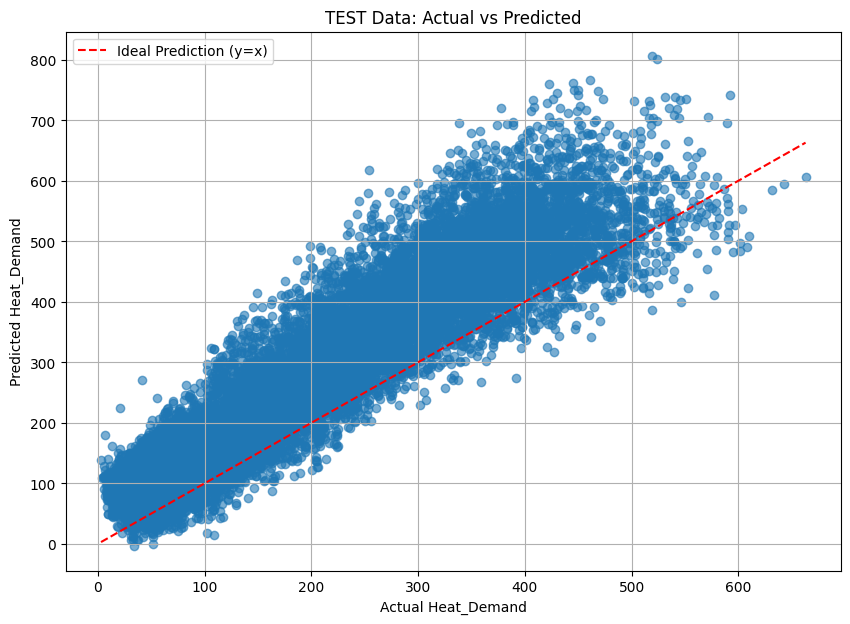

In [18]:
# SVR 시각화
plt.figure(figsize=(10, 7))
plt.scatter(y_test_original_scale, y_pred_original_scale, alpha=0.6)
plt.plot([min(y_test_original_scale), max(y_test_original_scale)],
         [min(y_test_original_scale), max(y_test_original_scale)],
         color='red', linestyle='--', label='Ideal Prediction (y=x)')
plt.title('TEST Data: Actual vs Predicted')
plt.xlabel('Actual Heat_Demand')
plt.ylabel('Predicted Heat_Demand')
plt.grid(True)
plt.legend()
plt.show()

## 3번 모델

In [33]:
# SVR 모델 생성 및 학습
from cuml.svm import SVR as cuML_SVR
import cupy as cp

# 데이터를 CuPy 배열로 변환 (GPU 메모리로 로드)
X_train_scaled_gpu = cp.asarray(X_train_scaled)
X_test_scaled_gpu = cp.asarray(X_test_scaled)
y_train_scaled_gpu = cp.asarray(y_train_scaled.ravel()) # SVR은 y를 1D 배열로 기대하므로 ravel() 사용

# SVR 모델 생성 및 학습 (cuML 버전)
svr_model_cuml = cuML_SVR(kernel='rbf', C=1, gamma=0.005, epsilon=0.01)

# 학습 (스케일링된 GPU 데이터 사용)
svr_model_cuml.fit(X_train_scaled_gpu, y_train_scaled_gpu)

# 예측 (스케일링된 GPU 데이터로 예측)
y_pred_scaled_gpu = svr_model_cuml.predict(X_test_scaled_gpu)

# 예측값 역변환하여 원래 스케일로 복원
# CuPy 배열을 다시 NumPy 배열로 변환
y_pred_original_scale = scaler_y.inverse_transform(y_pred_scaled_gpu.reshape(-1, 1).get()).flatten() # .get()으로 GPU -> CPU

# 실제 y_test 값
y_test_original_scale = y_test.values

# RMSE 계산
rmse = np.sqrt(mean_squared_error(y_test_original_scale, y_pred_original_scale))

# R-squared 계산
r2 = r2_score(y_test_original_scale, y_pred_original_scale)

print(f"\n--- 최종 cuML SVR 모델 성능 ---")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

SVR()


--- 최종 cuML SVR 모델 성능 ---
RMSE: 30.7338
R-squared: 0.9472


<Figure size 1500x500 with 0 Axes>

<Axes: >

<Axes: >

Text(0.5, 0, 'Predicted Heat_Demand')

Text(0, 0.5, 'Residuals (Actual - Predicted)')

...

<Axes: >

<Axes: ylabel='Count'>

Text(0.5, 0, 'Residuals')

Text(0, 0.5, 'Frequency')

Text(0.5, 1.0, 'Distribution of Residuals')

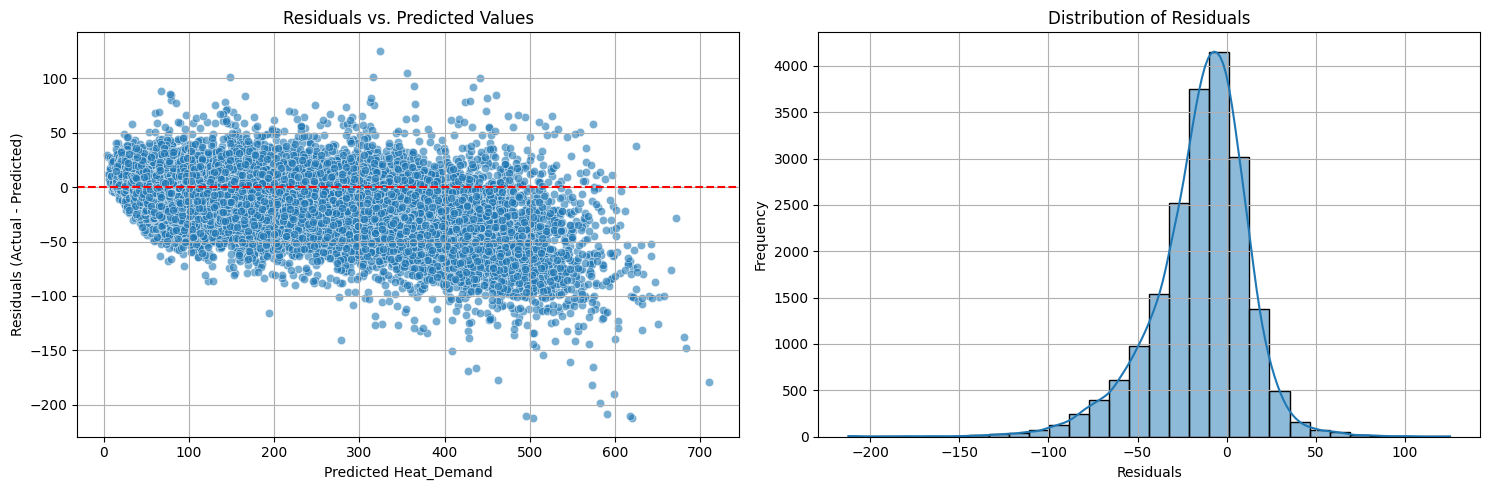

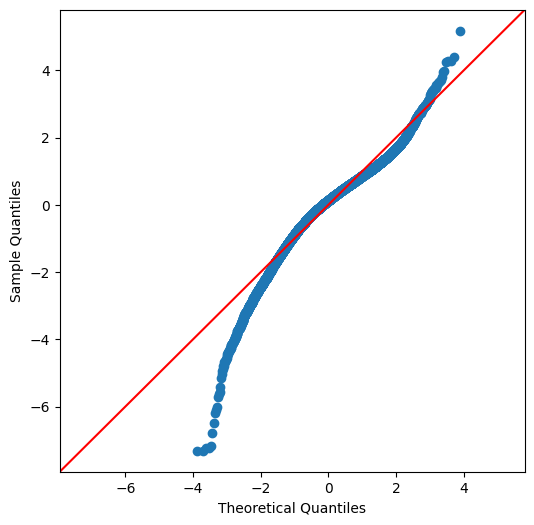

Text(0.5, 1.0, 'Q-Q Plot of Residuals')

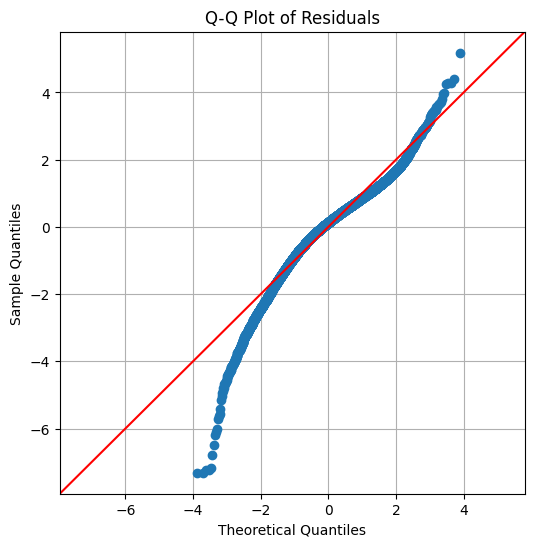

In [35]:
# 시각화를 위한 라이브러리 임포트
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 잔차 계산
residuals = y_test_original_scale - y_pred_original_scale

plt.figure(figsize=(15, 5))

# 1. 잔차 산점도 (Residuals vs. Predicted Values)
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_original_scale, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--') # 잔차가 0인 기준선
plt.xlabel("Predicted Heat_Demand")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs. Predicted Values")
plt.grid(True)
# 이상적인 잔차 산점도: 잔차들이 0을 중심으로 무작위로 분포하며, 특별한 패턴(V자형, U자형, 퍼지는 형태 등)이 없어야 함.

# 2. 잔차 히스토그램
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.grid(True)
# 이상적인 잔차 히스토그램: 종 모양의 정규 분포에 가까워야 함 (평균이 0에 가까움).

plt.tight_layout()
plt.show()

# 3. Q-Q Plot (Quantile-Quantile Plot)
# 잔차가 정규 분포를 따르는지 시각적으로 확인 (선형성에 가까울수록 정규분포에 근사)
fig, ax = plt.subplots(figsize=(6, 6))
sm.qqplot(residuals, line='45', fit=True, ax=ax) # line='45'는 y=x 선, fit=True는 데이터에 맞게 선형 회귀선 그림
ax.set_title("Q-Q Plot of Residuals")
plt.grid(True)
plt.show()